In [1]:
import requests

latitude = 32.0603
longitude = 118.7969

url = f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&current_weather=true"

response = requests.get(url)
data = response.json()

current = data["current_weather"]

print("Temperature:", current["temperature"], "°C")
print("Wind Speed:", current["windspeed"], "km/h")
print("Weather Code:", current["weathercode"])

Temperature: 9.5 °C
Wind Speed: 8.7 km/h
Weather Code: 3


In [13]:
import requests
import pandas as pd
from datetime import datetime, timedelta

# Nanjing coordinates
latitude = 32.0603
longitude = 118.7969

end_date = datetime.today().date()
start_date = end_date - timedelta(days=29)

url = (
    f"https://api.open-meteo.com/v1/forecast?"
    f"latitude={latitude}&longitude={longitude}"
    f"&daily=temperature_2m_max,windspeed_10m_max,precipitation_sum"
    f"&start_date={start_date}&end_date={end_date}"
    f"&timezone=auto"
)

response = requests.get(url)
data = response.json()

df = pd.DataFrame({
    "date": data["daily"]["time"],
    "temperature": data["daily"]["temperature_2m_max"],
    "wind_speed": data["daily"]["windspeed_10m_max"],
    "precipitation": data["daily"]["precipitation_sum"]
})

print("Number of days:", len(df))  
print(df)

df.to_csv("nanjing_weather_30_days.csv", index=False)

Number of days: 30
          date  temperature  wind_speed  precipitation
0   2026-02-16          5.2        25.3           12.3
1   2026-02-17          8.9         5.9            0.0
2   2026-02-18         12.8         9.4            0.0
3   2026-02-19         13.6        12.5            0.0
4   2026-02-20         18.4        18.7            0.0
5   2026-02-21         22.0        22.9            0.0
6   2026-02-22         22.0        18.1            0.0
7   2026-02-23         15.3        26.9            4.9
8   2026-02-24          9.5        16.6           11.1
9   2026-02-25         11.5        13.2            0.0
10  2026-02-26          9.1        13.1            9.2
11  2026-02-27         10.3         9.5            0.0
12  2026-02-28         12.7        17.7            0.9
13  2026-03-01         11.9        15.9           19.3
14  2026-03-02         10.1        14.3            0.8
15  2026-03-03          9.0        10.4            0.0
16  2026-03-04          9.5        15.6       

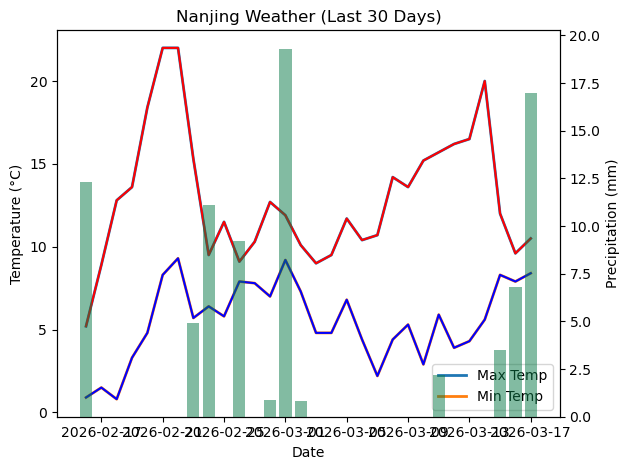

In [16]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

latitude = 32.0603
longitude = 118.7969

end_date = datetime.today().date()
start_date = end_date - timedelta(days=29)

url = (
    f"https://api.open-meteo.com/v1/forecast?"
    f"latitude={latitude}&longitude={longitude}"
    f"&daily=temperature_2m_max,temperature_2m_min,precipitation_sum"
    f"&start_date={start_date}&end_date={end_date}"
    f"&timezone=auto"
)

data = requests.get(url).json()

df = pd.DataFrame({
    "date": pd.to_datetime(data["daily"]["time"]),
    "temp_max": data["daily"]["temperature_2m_max"],
    "temp_min": data["daily"]["temperature_2m_min"],
    "precipitation": data["daily"]["precipitation_sum"]
})

fig, ax1 = plt.subplots()

ax1.plot(df["date"], df["temp_max"], label="Max Temp", linewidth=2)
ax1.plot(df["date"], df["temp_min"], label="Min Temp", linewidth=2)

ax1.set_xlabel("Date")
ax1.set_ylabel("Temperature (°C)")

ax2 = ax1.twinx()
ax2.bar(df["date"], df["precipitation"], alpha=0.3)
ax2.set_ylabel("Precipitation (mm)")

plt.title("Nanjing Weather (Last 30 Days)")
ax1.legend()
ax1.plot(df["date"], df["temp_max"], color="red", label="Max Temp")
ax1.plot(df["date"], df["temp_min"], color="blue", label="Min Temp")
ax2.bar(df["date"], df["precipitation"], color="green", alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [1]:
import requests

BASE_URL = "https://missionlocal.org/wp-json/wp/v2/posts"
HEADERS = {"User-Agent": "Mozilla/5.0 (AcademicResearch/1.0)"}

params = {
    "search": "police stop race",
    "per_page": 5,
    "_fields": "title,date,link"
}

response = requests.get(BASE_URL, headers=HEADERS, params=params, timeout=10)

print("Status code:", response.status_code)

posts = response.json()
for post in posts:
    print(post["title"]["rendered"])
    print("  Date:", post["date"][:10])
    print("  URL:", post["link"])

Status code: 200
Mission Local&#8217;s favorite Mission Local stories of 2025
  Date: 2025-12-31
  URL: https://missionlocal.org/2025/12/mission-locals-favorite-mission-local-stories-of-2025/
How to host a hot pot party for the holidays, and where to get all you need
  Date: 2025-12-30
  URL: https://missionlocal.org/2025/12/sf-hot-pot-party-grocery-market/
What went wrong in Ward 86? The hours and minutes leading up to Alberto Rangel&#8217;s killing.
  Date: 2025-12-22
  URL: https://missionlocal.org/2025/12/sf-hospital-killing-timeline/
RV dwellers say S.F. outreach worker is selling parking permits for cash
  Date: 2025-12-17
  URL: https://missionlocal.org/2025/12/sf-rv-dwellers-parking-permits-scam/
Alan Wong has been a progressive. He’s been a moderate. Now, he’s the Sunset supervisor.
  Date: 2025-12-01
  URL: https://missionlocal.org/2025/12/sf-alan-wong-district-supervisor-sunset/


In [6]:
import requests
import time
import html
import pandas as pd
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

BASE_URL = "https://missionlocal.org/wp-json/wp/v2/posts"
HEADERS = {"User-Agent": "Mozilla/5.0 (AcademicResearch/1.0)"}

session = requests.Session()
retry = Retry(total=3, backoff_factor=2, status_forcelist=[500, 502, 503, 504])
session.mount("https://", HTTPAdapter(max_retries=retry))

KEYWORDS = {
    "X_policy": [
        "DGO 9.07", "implicit bias training", "SFPD reform", "police accountability"
    ],
    "Y_disparity": [
        "racial disparity", "Black driver", "disproportionate stops", "RIPA data"
    ],
    "Z_discretion": [
        "officer discretion", "pretextual stop", "consent search", "police bias"
    ],
    "context": [
        "police stop race", "traffic stop", "use of force", "racial profiling"
    ]
}

all_posts = {}

for tag, keywords in KEYWORDS.items():
    for keyword in keywords:
        print(f"[{tag}] '{keyword}'")
        page = 1
        while True:
            params = {
                "search":   keyword,
                "per_page": 100,
                "page":     page,
                "after":    "2022-07-01T00:00:00",
                "before":   "2026-03-18T23:59:59",
                "_fields":  "id,title,date,link"
            }
            try:
                r = session.get(BASE_URL, headers=HEADERS, params=params, timeout=30)
            except requests.exceptions.Timeout:
                print(f"  Timeout, skipping page {page}")
                break
            except requests.exceptions.RequestException as e:
                print(f"  Error: {e}")
                break

            if r.status_code != 200:
                break

            posts = r.json()
            if not posts:
                break

            for post in posts:
                pid = post["id"]
                if pid not in all_posts:
                    all_posts[pid] = {
                        "id":      pid,
                        "title":   html.unescape(post["title"]["rendered"]),
                        "date":    post["date"][:10],
                        "url":     post["link"],
                        "tag":     tag,
                        "keyword": keyword
                    }

            total_pages = int(r.headers.get("X-WP-TotalPages", 1))
            print(f"  Page {page}/{total_pages} | unique so far: {len(all_posts)}")
            if page >= total_pages:
                break
            page += 1
            time.sleep(2)

df = pd.DataFrame(all_posts.values())
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

print(f"\nTotal articles: {len(df)}")
print(df.groupby("tag").size())

df.to_csv("relevant_articles_v2.csv", index=False, encoding="utf-8-sig")
print("Saved to relevant_articles_v2.csv")

[X_policy] 'DGO 9.07'
  Page 1/1 | unique so far: 2
[X_policy] 'implicit bias training'
  Page 1/1 | unique so far: 3
[X_policy] 'SFPD reform'
  Page 1/2 | unique so far: 101
  Page 2/2 | unique so far: 116
[X_policy] 'police accountability'
  Page 1/3 | unique so far: 200
  Page 2/3 | unique so far: 278
  Page 3/3 | unique so far: 299
[Y_disparity] 'racial disparity'
  Page 1/1 | unique so far: 304
[Y_disparity] 'Black driver'
  Page 1/2 | unique so far: 385
  Page 2/2 | unique so far: 405
[Y_disparity] 'disproportionate stops'
  Page 1/1 | unique so far: 409
[Y_disparity] 'RIPA data'
  Page 1/1 | unique so far: 409
[Z_discretion] 'officer discretion'
  Page 1/1 | unique so far: 423
[Z_discretion] 'pretextual stop'
  Page 1/1 | unique so far: 425
[Z_discretion] 'consent search'
  Page 1/1 | unique so far: 434
[Z_discretion] 'police bias'
  Page 1/1 | unique so far: 450
[context] 'police stop race'
  Page 1/2 | unique so far: 526
  Page 2/2 | unique so far: 575
[context] 'traffic stop'

In [12]:
!pip install vaderSentiment

In [14]:
import requests
import time
import pandas as pd
from bs4 import BeautifulSoup
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

HEADERS = {"User-Agent": "Mozilla/5.0 (AcademicResearch/1.0)"}

# 读取之前的文章列表，只分析最相关的两个tag
df = pd.read_csv("/Users/thisisjasmine/Desktop/relevant_articles_v2.csv")
df["date"] = pd.to_datetime(df["date"])
df = df[df["tag"].isin(["Y_disparity", "Z_discretion"])].copy()
print(f"Articles to scrape: {len(df)}")

# ── 第一步：抓正文 ──
def get_full_text(url):
    try:
        r = requests.get(url, headers=HEADERS, timeout=20)
        soup = BeautifulSoup(r.text, "html.parser")
        body = soup.find(class_="entry-content")
        if body:
            return body.get_text(separator=" ", strip=True)
    except:
        pass
    return ""

df["full_text"] = ""
for i, row in df.iterrows():
    print(f"[{i+1}/{len(df)}] {row['title'][:60]}")
    df.at[i, "full_text"] = get_full_text(row["url"])
    time.sleep(1.5)

# ── 第二步：情绪分析 ──
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if not text:
        return None, None, None, None
    scores = analyzer.polarity_scores(text)
    return scores["pos"], scores["neg"], scores["neu"], scores["compound"]

df[["pos", "neg", "neu", "compound"]] = df["full_text"].apply(
    lambda t: pd.Series(get_sentiment(t))
)

# compound: +1 = 最正面, -1 = 最负面
# 分类
def label(c):
    if c >= 0.05:  return "Positive"
    if c <= -0.05: return "Negative"
    return "Neutral"

df["sentiment"] = df["compound"].apply(label)
df["period"] = df["date"].apply(
    lambda d: "Post-DGO 9.07" if d >= pd.Timestamp("2024-07-17") else "Pre-DGO 9.07"
)

# ── 第三步：保存 + 预览 ──
df.to_csv("articles_sentiment.csv", index=False, encoding="utf-8-sig")

print("\n── Sentiment by Period ──")
print(df.groupby(["period", "sentiment"]).size().unstack(fill_value=0))

print("\n── Average Compound Score ──")
print(df.groupby("period")["compound"].mean())

Articles to scrape: 151
[16/151] Fellow mayoral school board appointees split from embattled 
[21/151] Activists bring heat at fiery traffic-stop discussion with S
[24/151] Gunshots fired at 21st and Mission intersection
[28/151] The app always wins: a DoorDash driver’s quixotic quest for 
[36/151] ‘All up for work:’ Immigrant Uber and Lyft drivers create co
[37/151] Smashed cars, terrified pedestrians, physical threats: Reckl
[48/151] Latinx communities join SFPD traffic stop discussion
[57/151] Neighborhood Notes: Slate* fundraiser, Dog Eared turns 30
[78/151] After 2-year lapse, SFPD promises sex work crackdown on Capp
[95/151] Input on SFPD traffic stops picks up at Glide’s police-free 
[130/151] Motorcyclist killed in SF Mission collision
[148/151] New Year’s Day driver kills SF woman, flees scene
[149/151] Suspected drunk driver scares McDonald’s crowd after driving
[157/151] Public Defender moves to disqualify DA from Troy McAlister c
[166/151] Five claims from Uber’s rosy 2022 

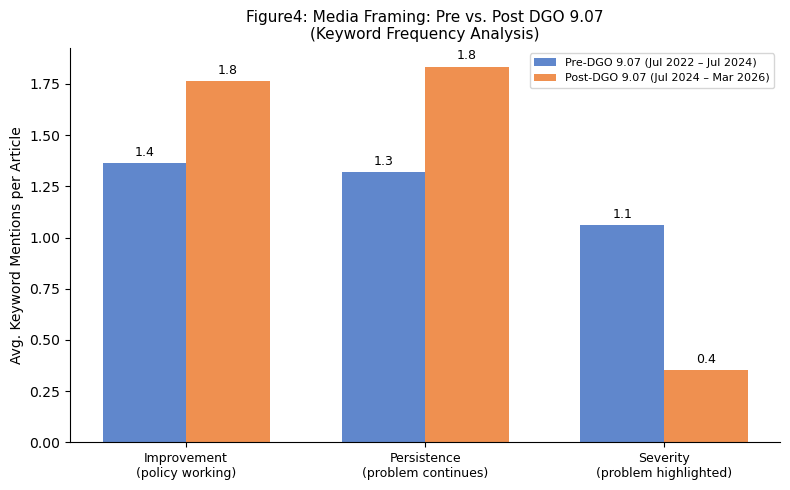

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── 读取数据 ─────────────────────────
df = pd.read_csv("/Users/thisisjasmine/Desktop/articles_sentiment.csv")
df["date"] = pd.to_datetime(df["date"])
df = df[df["full_text"].notna() & (df["full_text"] != "")]

POLICY_DATE = pd.Timestamp("2024-07-17")

# ── 关键词框架 ───────────────────────
frames = {
    "Improvement\n(policy working)": [
        "decreased", "declined", "reduced", "fell", "drop", "improved",
        "less likely", "progress", "lower"
    ],
    "Persistence\n(problem continues)": [
        "persists", "still", "continues", "ongoing", "remains", "despite",
        "unchanged", "entrenched"
    ],
    "Severity\n(problem highlighted)": [
        "disparity", "disproportionate", "bias", "discriminat", "over-polic",
        "racial gap", "inequality"
    ]
}

# ── 计数函数 ─────────────────────────
def count_frame(text, keywords):
    text = text.lower()
    return sum(text.count(k.lower()) for k in keywords)

# ── 生成变量 ─────────────────────────
for frame, keywords in frames.items():
    df[frame] = df["full_text"].apply(lambda t: count_frame(t, keywords))

df["period"] = df["date"].apply(
    lambda d: "Post-DGO 9.07\n(Jul 2024 – Mar 2026)"
    if d >= POLICY_DATE else "Pre-DGO 9.07\n(Jul 2022 – Jul 2024)"
)

# ── 汇总 ─────────────────────────────
frame_cols = list(frames.keys())
frame_avg = df.groupby("period")[frame_cols].mean()

# ── 作图（单图版本）──────────────────
fig, ax = plt.subplots(figsize=(8, 5))

periods = [
    "Pre-DGO 9.07\n(Jul 2022 – Jul 2024)",
    "Post-DGO 9.07\n(Jul 2024 – Mar 2026)"
]

x = np.arange(len(frame_cols))
w = 0.35
colors_period = ["#4472C4", "#ED7D31"]

for i, (period, color) in enumerate(zip(periods, colors_period)):
    vals = [frame_avg.loc[period, f] for f in frame_cols]
    bars = ax.bar(
        x + (i - 0.5) * w,
        vals,
        w,
        label=period.replace("\n", " "),
        color=color,
        alpha=0.85
    )
    
    # 数值标签
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{v:.1f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

# ── 美化 ─────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(frame_cols, fontsize=9)
ax.set_ylabel("Avg. Keyword Mentions per Article", fontsize=10)

ax.set_title(
    "Figure4: Media Framing: Pre vs. Post DGO 9.07\n(Keyword Frequency Analysis)",
    fontsize=11
)

ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

# ── 保存 ─────────────────────────────
plt.tight_layout()
plt.savefig("chart1_framing.png", dpi=300, bbox_inches="tight")

plt.show()

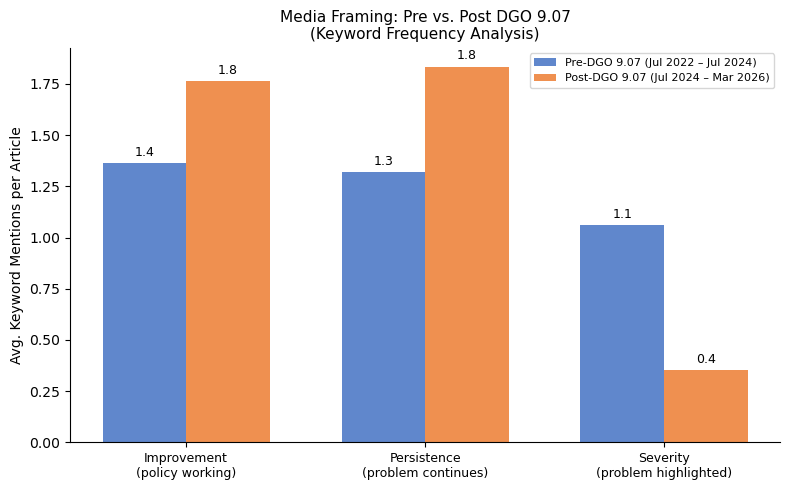

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── 读取数据 ─────────────────────────
df = pd.read_csv("/Users/thisisjasmine/Desktop/articles_sentiment.csv")
df["date"] = pd.to_datetime(df["date"])
df = df[df["full_text"].notna() & (df["full_text"] != "")]

POLICY_DATE = pd.Timestamp("2024-07-17")

# ── 关键词框架 ───────────────────────
frames = {
    "Improvement\n(policy working)": [
        "decreased", "declined", "reduced", "fell", "drop", "improved",
        "less likely", "progress", "lower"
    ],
    "Persistence\n(problem continues)": [
        "persists", "still", "continues", "ongoing", "remains", "despite",
        "unchanged", "entrenched"
    ],
    "Severity\n(problem highlighted)": [
        "disparity", "disproportionate", "bias", "discriminat", "over-polic",
        "racial gap", "inequality"
    ]
}

# ── 计数函数 ─────────────────────────
def count_frame(text, keywords):
    text = text.lower()
    return sum(text.count(k.lower()) for k in keywords)

# ── 生成变量 ─────────────────────────
for frame, keywords in frames.items():
    df[frame] = df["full_text"].apply(lambda t: count_frame(t, keywords))

df["period"] = df["date"].apply(
    lambda d: "Post-DGO 9.07\n(Jul 2024 – Mar 2026)"
    if d >= POLICY_DATE else "Pre-DGO 9.07\n(Jul 2022 – Jul 2024)"
)

# ── 汇总 ─────────────────────────────
frame_cols = list(frames.keys())
frame_avg = df.groupby("period")[frame_cols].mean()

# ── 作图（单图版本）──────────────────
fig, ax = plt.subplots(figsize=(8, 5))

periods = [
    "Pre-DGO 9.07\n(Jul 2022 – Jul 2024)",
    "Post-DGO 9.07\n(Jul 2024 – Mar 2026)"
]

x = np.arange(len(frame_cols))
w = 0.35
colors_period = ["#4472C4", "#ED7D31"]

for i, (period, color) in enumerate(zip(periods, colors_period)):
    vals = [frame_avg.loc[period, f] for f in frame_cols]
    bars = ax.bar(
        x + (i - 0.5) * w,
        vals,
        w,
        label=period.replace("\n", " "),
        color=color,
        alpha=0.85
    )
    
    # 数值标签
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{v:.1f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

# ── 美化 ─────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(frame_cols, fontsize=9)
ax.set_ylabel("Avg. Keyword Mentions per Article", fontsize=10)

ax.set_title(
    "Media Framing: Pre vs. Post DGO 9.07\n(Keyword Frequency Analysis)",
    fontsize=11
)

ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

# ── 保存 ─────────────────────────────
plt.tight_layout()
plt.savefig("chart1_framing.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
for i, (period, color) in enumerate(zip(periods, colors_period)):
    vals = [frame_avg.loc[period, f] for f in frame_cols]
    bars = ax.bar(x + (i - 0.5) * w, vals, w,
                  label=period.replace("\n", " "), color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{v:.1f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(frame_cols, fontsize=9)
ax.set_ylabel("Avg. Keyword Mentions per Article", fontsize=10)
ax.set_title("Figure4: Media Framing: Pre vs. Post DGO 9.07\n(Keyword Frequency Analysis)", fontsize=11)
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("chart1_framing.png", dpi=150, bbox_inches="tight")
plt.show()